In [1]:
import pandas as pd
import numpy as np
print("clase 1 - entorno y notebook ok")


clase 1 - entorno y notebook ok


In [2]:
np.random.seed(1)

docs = [f"DOC{str(i).zfill(4)}" for i in range(1, 101)]
rows = []

for d in docs:
    monto = np.random.randint(50_000, 1_500_000)
    fecha = pd.Timestamp("2024-01-01") + pd.to_timedelta(np.random.randint(0, 45), unit="D")
    usuario = np.random.choice(["usr01", "usr02", "usr03", "usr09"])

    rows.append([fecha, "110301", "Clientes", monto, 0, d, usuario])
    rows.append([fecha, "410101", "Ingresos", 0, monto, d, usuario])

gl = pd.DataFrame(rows, columns=[
    "fecha", "cuenta", "nombre_cuenta", "debe", "haber", "id_doc", "usuario"
])

# Introducimos errores intencionales
gl.loc[10, "haber"] += 120_000
gl.loc[55, "debe"] = 0

gl.head()


,fecha,cuenta,nombre_cuenta,debe,haber,id_doc,usuario
0,2024-02-13,110301,Clientes,178037,0,DOC0001,usr01
1,2024-02-13,410101,Ingresos,0,178037,DOC0001,usr01
2,2024-01-10,110301,Clientes,541263,0,DOC0002,usr09
3,2024-01-10,410101,Ingresos,0,541263,DOC0002,usr09
4,2024-01-16,110301,Clientes,123349,0,DOC0003,usr01


In [3]:
control_balance = (
    gl.groupby("id_doc")[["debe", "haber"]]
      .sum()
      .assign(diferencia=lambda x: x["debe"] - x["haber"])
      .reset_index()
)

control_balance


,id_doc,debe,haber,diferencia
0,DOC0001,178037,178037,0
1,DOC0002,541263,541263,0
2,DOC0003,123349,123349,0
3,DOC0004,279520,279520,0
4,DOC0005,975255,975255,0
...,...,...,...,...
95,DOC0096,927894,927894,0
96,DOC0097,609344,609344,0
97,DOC0098,371718,371718,0
98,DOC0099,1150560,1150560,0


In [4]:
hallazgos = control_balance[control_balance["diferencia"] !=0]
hallazgos

,id_doc,debe,haber,diferencia
5,DOC0006,1091586,1211586,-120000


In [5]:
gl[gl["id_doc"] == "DOC0006"]

,fecha,cuenta,nombre_cuenta,debe,haber,id_doc,usuario
10,2024-01-21,110301,Clientes,1091586,120000,DOC0006,usr03
11,2024-01-21,410101,Ingresos,0,1091586,DOC0006,usr03


In [6]:
gl["riesgo_balance"] = gl["id_doc"].isin(hallazgos["id_doc"])
gl.head(10)

,fecha,cuenta,nombre_cuenta,debe,haber,id_doc,usuario,riesgo_balance
0,2024-02-13,110301,Clientes,178037,0,DOC0001,usr01,False
1,2024-02-13,410101,Ingresos,0,178037,DOC0001,usr01,False
2,2024-01-10,110301,Clientes,541263,0,DOC0002,usr09,False
3,2024-01-10,410101,Ingresos,0,541263,DOC0002,usr09,False
4,2024-01-16,110301,Clientes,123349,0,DOC0003,usr01,False
5,2024-01-16,410101,Ingresos,0,123349,DOC0003,usr01,False
6,2024-01-02,110301,Clientes,279520,0,DOC0004,usr01,False
7,2024-01-02,410101,Ingresos,0,279520,DOC0004,usr01,False
8,2024-01-07,110301,Clientes,975255,0,DOC0005,usr02,False
9,2024-01-07,410101,Ingresos,0,975255,DOC0005,usr02,False


In [7]:
resumen = hallazgos.assign(
    abs_diferencia=lambda x: x["diferencia"].abs()
)
resumen

,id_doc,debe,haber,diferencia,abs_diferencia
5,DOC0006,1091586,1211586,-120000,120000


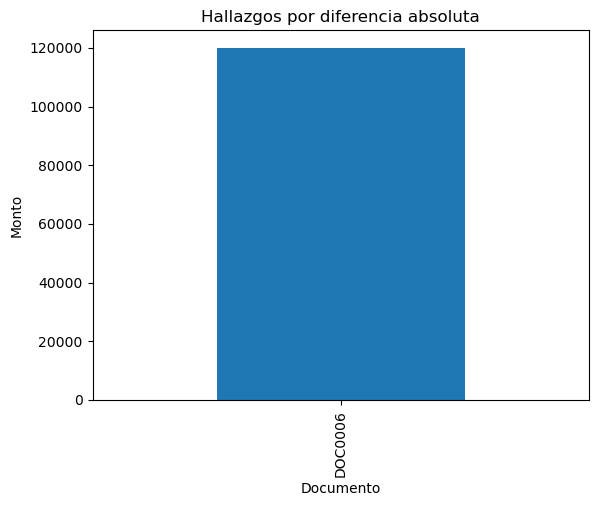

In [8]:
import matplotlib.pyplot as plt

resumen.plot(
    x="id_doc",
    y="abs_diferencia",
    kind="bar",
    legend=False,
    title="Hallazgos por diferencia absoluta"
)

plt.ylabel("Monto")
plt.xlabel("Documento")
plt.show()


In [9]:
# Simulamos corrección contable del error
gl_corregido = gl.copy()

gl_corregido.loc[
    (gl_corregido["id_doc"] == "DOC0006") & (gl_corregido["haber"] > 0),
    "haber"
] -= 120_000


In [10]:
control_post = (
    gl_corregido.groupby("id_doc")[["debe", "haber"]]
      .sum()
      .assign(diferencia=lambda x: x["debe"] - x["haber"])
)

control_post[control_post["diferencia"] != 0]


,debe,haber,diferencia
id_doc,,,
DOC0006,1091586,971586,120000


In [11]:
git add .
git commit -m "Clase 1: visualización de hallazgos y validación del control"
git push


SyntaxError: invalid syntax (598118799.py, line 1)

In [12]:
pwd audit-analytics-diplomado

'C:\\Users\\caagu\\OneDrive\\Escritorio\\Carlos\\0_Analisis de Datos\\audit-analytics-diplomado\\Notebooks'

In [13]:
git add .
git commit -m "Clase 1: visualización de hallazgos y validación del control"
git push

SyntaxError: invalid syntax (1010689901.py, line 1)